### Простая предобработка датасета

In [2]:
import pandas as pd

In [3]:
def clean_transcription(transcription):
    transcription = transcription.replace("ˈ", "") # убираем ударение
    transcription = transcription.replace("ˌ", "") # убираем вторичное ударение
    
    return transcription[2:-2] # отсекаем слеши в начале и в конце

In [4]:
df = pd.read_csv("labeled_dataset_V2.txt", delimiter=" № ", 
                 header=None, names=[
                     "word",
                     "transcription",
                     "gender",
                     "url"
                 ])

/tmp/ipykernel_23577/277580749.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv("labeled_dataset_V2.txt", delimiter=" № ",


In [5]:
df["transcription"] = df["transcription"].apply(clean_transcription)

In [6]:
df.head()

,word,transcription,gender,url
0,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...
1,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...
2,aaron,ɛərən,женщина,https://audio12.forvo.com/audios/mp3/l/9/l9_93...
3,aaronic,ɛərɒnɪk,мужчина,https://audio12.forvo.com/audios/mp3/7/8/78_89...
4,abaca,æbəkə,мужчина,https://audio12.forvo.com/audios/mp3/2/o/2o_89...


In [7]:
len(set(df["word"]))

15499

## Оценка баланса мужских и женских записей

In [8]:
df.gender.unique()

array(['мужчина', 'женщина', 'неизвестно', 'Из Великобритания)'],
      dtype=object)

In [9]:
df[df.gender == 'неизвестно'] # нужно разметить или просто дропнуть

,word,transcription,gender,url
104,abusive,əbjuːsɪv,неизвестно,https://audio12.forvo.com/audios/mp3/g/5/g5_95...
1123,apricot,eɪprɪkɒt,неизвестно,https://audio12.forvo.com/audios/mp3/y/r/yr_95...
1536,autocracy,ɔːtɒkrəsɪ,неизвестно,https://audio12.forvo.com/audios/mp3/3/v/3v_95...
1549,autonomous,ɔːtɒnəməs,неизвестно,https://audio12.forvo.com/audios/mp3/t/g/tg_95...
1560,avalanche,ævəlɑːntʃ,неизвестно,https://audio12.forvo.com/audios/mp3/u/1/u1_10...
...,...,...,...,...
19736,tsunami,tsʊnæmɪ,неизвестно,https://audio12.forvo.com/audios/mp3/d/c/dc_10...
20196,unsubstantiated,ʌnsəbstænʃɪeɪtɪd,неизвестно,https://audio12.forvo.com/audios/mp3/9/0/90_95...
20628,visibility,vɪzɪbɪlɪtɪ,неизвестно,https://audio12.forvo.com/audios/mp3/x/d/xd_10...
20679,volcano,vɒlkeɪnəʊ,неизвестно,https://audio12.forvo.com/audios/mp3/d/y/dy_10...


In [10]:
df[df.gender == 'Из Великобритания)'] # аналогично

,word,transcription,gender,url
1916,beautiful,bjuːtɪfʊl,Из Великобритания),https://audio12.forvo.com/audios/mp3/k/8/k8_95...
2607,brigid,brɪdʒɪd,Из Великобритания),https://audio12.forvo.com/audios/mp3/u/8/u8_91...
4001,colour,kʌlə,Из Великобритания),https://audio12.forvo.com/audios/mp3/j/a/ja_95...
5027,dana,deɪnə,Из Великобритания),https://audio12.forvo.com/audios/mp3/b/i/bi_91...
6006,doyle,dɔɪl,Из Великобритания),https://audio12.forvo.com/audios/mp3/3/x/3x_89...
6281,durham,dʌrəm,Из Великобритания),https://audio12.forvo.com/audios/mp3/t/7/t7_91...
6512,elegant,ɛlɪɡənt,Из Великобритания),https://audio12.forvo.com/audios/mp3/n/v/nv_95...
8973,harpsichord,hɑːpsɪkɔːd,Из Великобритания),https://audio12.forvo.com/audios/mp3/t/j/tj_96...
10022,indisputable,ɪndɪspjuːtəbəl,Из Великобритания),https://audio12.forvo.com/audios/mp3/c/n/cn_96...
12785,naomi,neɪəmɪ,Из Великобритания),https://audio12.forvo.com/audios/mp3/n/w/nw_91...


In [11]:
df_male = df[df.gender == "мужчина"]
print(len(df_male))

15583


In [12]:
df_female = df[df.gender == "женщина"]
print(len(df_female))

5706


In [13]:
df = pd.concat([df_male, df_female])

Как видно, имеется значительный дисбаланс мужских и женских записей (~ 3:1)

## Оценка баланса токенов

### Создадим для начала словарь фонем посимвольно

In [14]:
import matplotlib.pyplot as plt

In [15]:
def get_phonemes_frequencies(df):

    transcriptions_list = list(df["transcription"])
    phonemes_dict = {}
    for transcription in transcriptions_list:
        for phoneme in list(transcription):
            
            if not phoneme in phonemes_dict.keys():
                phonemes_dict[phoneme] = 1
            else:
                phonemes_dict[phoneme] += 1
                
    phonemes = list(phonemes_dict.keys())
    frequencies = list(phonemes_dict.values())
    
    return phonemes, frequencies

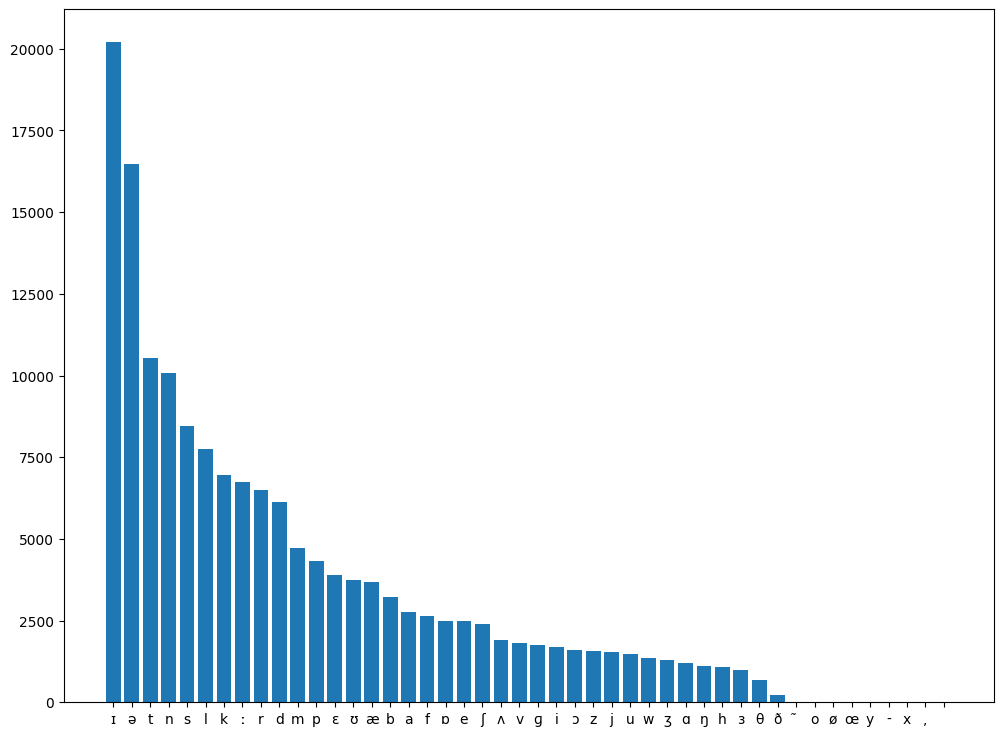

In [16]:
phonemes, frequencies = get_phonemes_frequencies(df)
frequencies_sorted, phonemes_sorted = zip(*sorted(zip(frequencies, phonemes), reverse=True))

fig, ax = plt.subplots(figsize=(12, 9))

ax.bar(phonemes_sorted, frequencies_sorted)
plt.show()

#### Имеется много некорректных для британских транскрипций символов - обработаем транскрипции с ними

In [17]:
def show_words_by_phoneme(phoneme, df):
    return df[df["transcription"].str.contains(phoneme)]

def drop_words_by_phoneme(phoneme, df):
    return df[~df["transcription"].str.contains(phoneme)]

def fix_transcription(word, fixed_transcription, df):
    df.loc[df["word"] == word, "transcription"] = fixed_transcription

In [18]:
show_words_by_phoneme("ø", df) # как видим, здесь какие-то имена, поэтому можно дропнуть

,word,transcription,gender,url
6948,eugene,øʒɛn,мужчина,https://audio12.forvo.com/audios/mp3/c/w/cw_10...
6949,eugenie,øʒeni,мужчина,https://audio12.forvo.com/audios/mp3/3/4/34_89...
8550,goethe,ɡøːtə,мужчина,https://audio12.forvo.com/audios/mp3/f/y/fy_97...
8600,goring,ɡøːrɪŋ,мужчина,https://audio12.forvo.com/audios/mp3/7/c/7c_95...


In [19]:
df_new = drop_words_by_phoneme("ø", df)

In [20]:
show_words_by_phoneme("y", df) # какие-то явно немецкие слова поэтому можно дропнуть

,word,transcription,gender,url
16684,schadenfreude,ʃaːdənfrɔydə,мужчина,https://audio12.forvo.com/audios/mp3/u/b/ub_95...
16685,schadenfreude,ʃaːdənfrɔydə,мужчина,https://audio12.forvo.com/audios/mp3/w/t/wt_10...


In [21]:
df_new = drop_words_by_phoneme("y", df_new)

In [22]:
show_words_by_phoneme("-", df) # здесь имеет место ошибка разметки

,word,transcription,gender,url
10343,interplanetary,"ɪntəplænɪtərɪ, -trɪ",мужчина,https://audio12.forvo.com/audios/mp3/9/i/9i_90...
11452,lived,-lɪvd,мужчина,https://audio12.forvo.com/audios/mp3/u/3/u3_89...


In [23]:
fix_transcription("interplanetary", "ɪntəplænɪtərɪ", df_new)
fix_transcription("lived", "lɪvd", df_new)

In [24]:
show_words_by_phoneme(",", df) # уже исправили это слово)

,word,transcription,gender,url
10343,interplanetary,"ɪntəplænɪtərɪ, -trɪ",мужчина,https://audio12.forvo.com/audios/mp3/9/i/9i_90...


In [25]:
show_words_by_phoneme('̃', df) # кажется, это слова из французского языка, поэтому тоже их дропнем

,word,transcription,gender,url
1002,antoinette,ɑ̃twanɛt,мужчина,https://audio12.forvo.com/audios/mp3/d/c/dc_90...
6744,entente,ɑ̃tɑ̃t,мужчина,https://audio12.forvo.com/audios/mp3/b/j/bj_89...
7617,flacon,flakɔ̃,мужчина,https://audio12.forvo.com/audios/mp3/7/f/7f_10...
7939,framboise,frɑ̃bwaz,мужчина,https://audio12.forvo.com/audios/mp3/n/y/ny_97...
8016,frisson,frisɔ̃,мужчина,https://audio12.forvo.com/audios/mp3/q/d/qd_89...
9994,indy,ɛ̃di,мужчина,https://audio12.forvo.com/audios/mp3/6/i/6i_89...
11394,lyon,ljɔ̃,мужчина,https://audio12.forvo.com/audios/mp3/0/0/00_94...
17782,soupcon,supsɔ̃,мужчина,https://audio12.forvo.com/audios/mp3/m/v/mv_90...
6696,enfleurage,ɑ̃flœraʒ,женщина,https://audio12.forvo.com/audios/mp3/0/s/0s_92...
6743,entente,ɑ̃tɑ̃t,женщина,https://audio12.forvo.com/audios/mp3/6/j/6j_90...


In [26]:
df_new = drop_words_by_phoneme('̃', df_new)

In [27]:
show_words_by_phoneme("œ", df) # также французские слова

,word,transcription,gender,url
139,accoucheur,akuʃœr,мужчина,https://audio12.forvo.com/audios/mp3/r/r/rr_94...
6696,enfleurage,ɑ̃flœraʒ,женщина,https://audio12.forvo.com/audios/mp3/0/s/0s_92...


In [28]:
df_new = drop_words_by_phoneme("œ", df_new)

In [29]:
show_words_by_phoneme("x", df) # какой-то топоним, дропаем

,word,transcription,gender,url
2393,bokhara,bʊxɑːrə,мужчина,https://audio12.forvo.com/audios/mp3/l/p/lp_94...


In [30]:
df_new = drop_words_by_phoneme("x", df_new)

In [31]:
show_words_by_phoneme("o", df) # заимствованные слова, валюта, топоним - дропаем

,word,transcription,gender,url
3663,cicisbeo,tʃitʃizbɛːo,мужчина,https://audio12.forvo.com/audios/mp3/q/r/qr_89...
6894,escargot,ɛskarɡo,мужчина,https://audio12.forvo.com/audios/mp3/0/2/02_95...
7862,forint,forint,мужчина,https://audio12.forvo.com/audios/mp3/k/g/kg_92...
15526,quahog,koʊhɒɡ,мужчина,https://audio12.forvo.com/audios/mp3/g/l/gl_89...
15527,quahog,koʊhɒɡ,мужчина,https://audio12.forvo.com/audios/mp3/o/w/ow_93...


In [32]:
df_new = drop_words_by_phoneme("o", df_new)

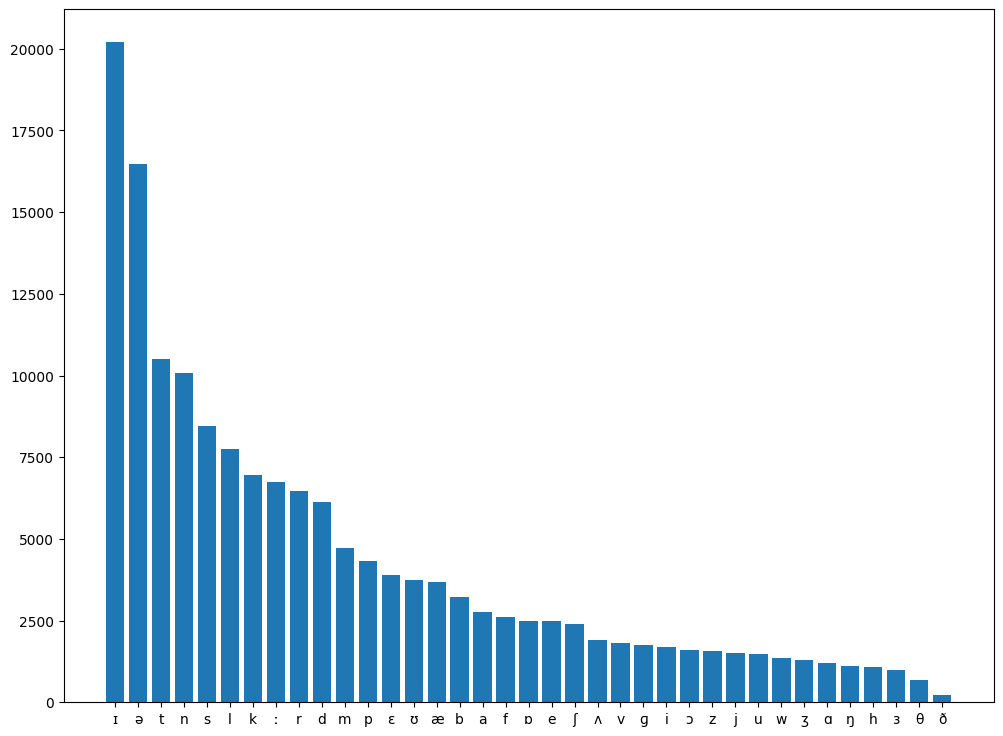

In [33]:
phonemes_new, frequencies_new = get_phonemes_frequencies(df_new)
fig, ax = plt.subplots(figsize=(12, 9))
frequencies_sorted, phonemes_sorted = zip(*sorted(zip(frequencies_new, phonemes_new), reverse=True))

ax.bar(phonemes_sorted, frequencies_sorted)
plt.show()

#### В датасете не осталось некорректных символов, но имеется другая проблема - разбиение просто по символам не учитывает тот факт, что в английском языке существуют звуки, записываемые 2 символами (протяжные звуки, дифтонги). Модифицируем с учётом этого подход к токенизации

### Создадим словарь, учитывающий дифтонги и протяжные звуки

#### 1. Создаём словари "одинарных" и "двойных" звуков

In [34]:
unary_phonemes_list = [
    "æ","ɪ", "ɛ", "ɒ", "ʊ", "ʌ", "ə",
    "p", "f", "t", "θ", "s", "ʃ", "k", "b", "v", "d", "ð", "z", "ʒ", "ɡ", "h", "m", "n", "ŋ", "r", "l", "w", "j" 
]

In [35]:
binary_phonemes_list = [
    "ɑː", "iː", "ɔː", "uː", "ɜː",
    "eɪ", "aɪ", "aʊ", "əʊ", "ɔɪ", "ɪə", "ɛə", "ʊə",
    "tʃ", "dʒ"
]

In [36]:
phonemes_list = unary_phonemes_list + binary_phonemes_list

In [37]:
assert(len(phonemes_list) == 44) # все источники говорят, что в английском языке 44 звука

#### 2. В датасете есть слова с некорректной транскрипцией (не бьются правильно на звуки) - обработаем их

In [38]:
def find_wrong_transcripts(df):
    transcriptions_list = list(df["transcription"])

    wrong_transcripts = []

    skip = False

    for transcription in transcriptions_list:
        for i in range(len(transcription)):
            
            if skip:
                skip = False
                continue
            
            if i < len(transcription) - 1:
                
                if transcription[i:i+2] in binary_phonemes_list:
                    skip = True
                
                elif transcription[i] in unary_phonemes_list:
                    pass
                    
                else:
                    wrong_transcripts.append(transcription)
                    
                continue
            
            if transcription[i] in unary_phonemes_list:
                pass
                    
            else:
                wrong_transcripts.append(transcription)
                
    return list(set(wrong_transcripts))

In [39]:
wrong_transcripts = find_wrong_transcripts(df_new)

In [40]:
def show_word_by_transcription(transcription, df):
    return list(df[df["transcription"] == transcription]["word"])[0]

def drop_word(word, df):
    return df[~(df["word"] == word)]

In [41]:
wrong_words = {}
for transcription in set(wrong_transcripts):
    wrong_words[show_word_by_transcription(transcription, df_new)] = transcription

In [42]:
wrong_words

{'paramedic': 'pærəmedɪk',
 'mann': 'man',
 'lafayette': 'lafajɛt',
 'canaille': 'kanɑj',
 'baku': 'baku',
 'valencia': 'balenθja',
 'irwin': 'ɛːwɪn',
 'gerard': 'ʒerar',
 'pinata': 'pɪnjata',
 'bismillah': 'bɪsmɪlaː',
 'moliere': 'mɔljɛr',
 'tours': 'tur',
 'snakehead': 'sneɪkhed',
 'ae': 'e',
 'mousseline': 'muslin',
 'sorbonne': 'sɔrbɔn',
 'underachieve': 'undərətʃiːv',
 'degage': 'deɡaʒe',
 'headmistress': 'hɛdmistrəs'}

In [43]:
fix_transcription("underachieve", "ʌndərətʃiːv", df_new)
del wrong_words["underachieve"]
fix_transcription("paramedic", "pærəmɛdɪk", df_new)
del wrong_words["paramedic"]

In [44]:
for word in wrong_words:
    df_new = drop_word(word, df_new)

#### 3. Подсчитаем частоты звуков

In [45]:
def get_phonemes_frequencies(df):
    
    assert(len(find_wrong_transcripts(df)) == 0)
    
    phonemes_dict = {phoneme: 0 for phoneme in phonemes_list}
    
    transcriptions_list = list(df["transcription"])

    skip = False

    for transcription in transcriptions_list:
        for i in range(len(transcription)):
            
            if skip:
                skip = False
                continue
            
            if i < len(transcription) - 1:
                
                if transcription[i:i+2] in binary_phonemes_list:
                    phonemes_dict[transcription[i:i+2]] += 1
                    skip = True
                
                elif transcription[i] in unary_phonemes_list:
                    phonemes_dict[transcription[i]] += 1
                    
                else:
                    wrong_transcripts.append(transcription)
                    
                continue
            
            if transcription[i] in unary_phonemes_list:
                phonemes_dict[transcription[i]] += 1
                    
            else:
                wrong_transcripts.append(transcription)
                
    phonemes = phonemes_dict.keys()
    frequencies = phonemes_dict.values()
                
    return phonemes, frequencies

In [46]:
df_new.to_csv("prepared_dataset.csv", sep="№")

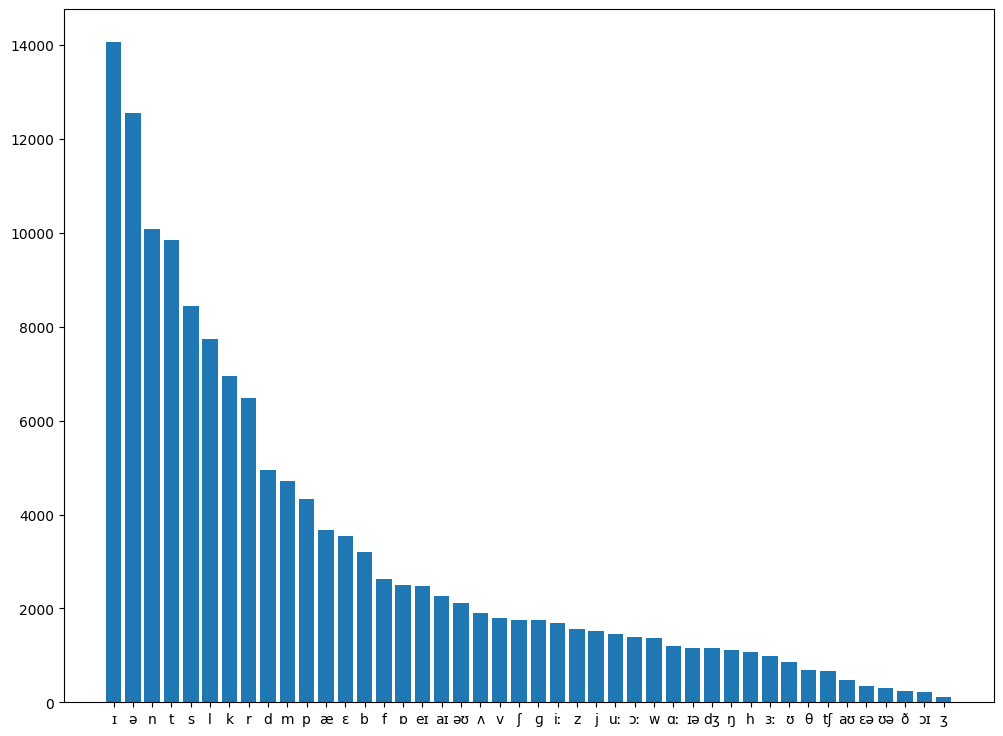

In [47]:
phonemes, frequencies = get_phonemes_frequencies(df_new)
frequencies_sorted, phonemes_sorted = zip(*sorted(zip(frequencies, phonemes), reverse=True))
fig, ax = plt.subplots(figsize=(12, 9))

ax.bar(phonemes_sorted, frequencies_sorted)
plt.show()

#### Также отдельно выведим баланс для мужских и женских голосов

In [48]:
df_male = df_new[df_new["gender"] == "мужчина"]
df_female = df_new[df_new["gender"] == "женщина"]

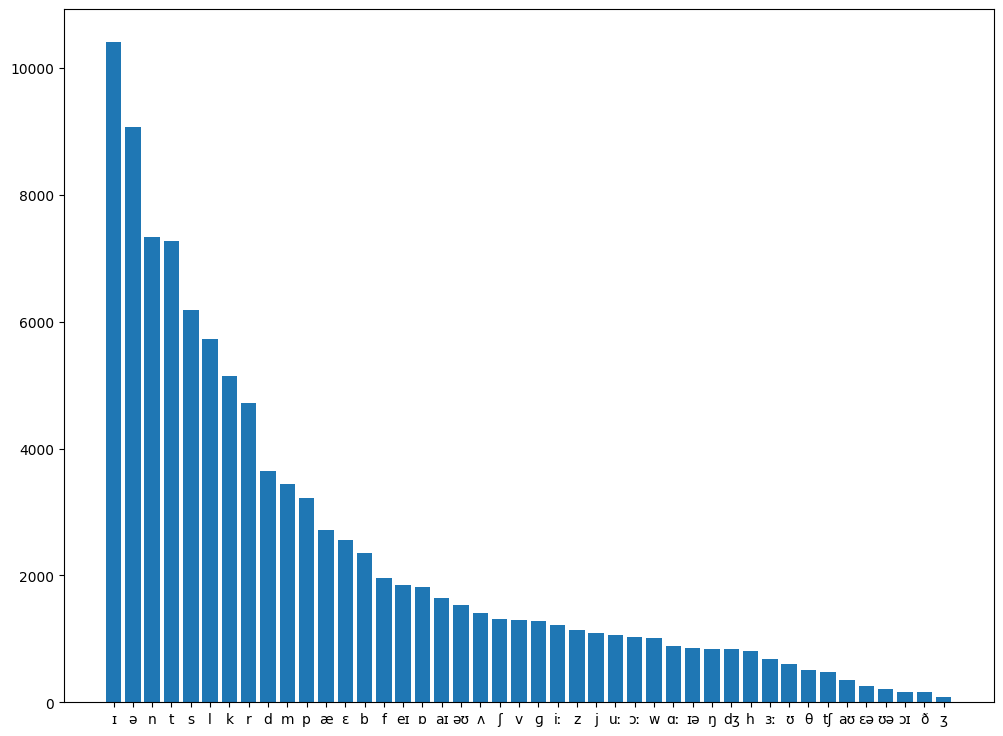

In [49]:
phonemes_male, frequencies_male = get_phonemes_frequencies(df_male)
frequencies_male_sorted, phonemes_male_sorted = zip(*sorted(zip(frequencies_male, phonemes_male), reverse=True))
fig, ax = plt.subplots(figsize=(12, 9))

ax.bar(phonemes_male_sorted, frequencies_male_sorted)
plt.show()

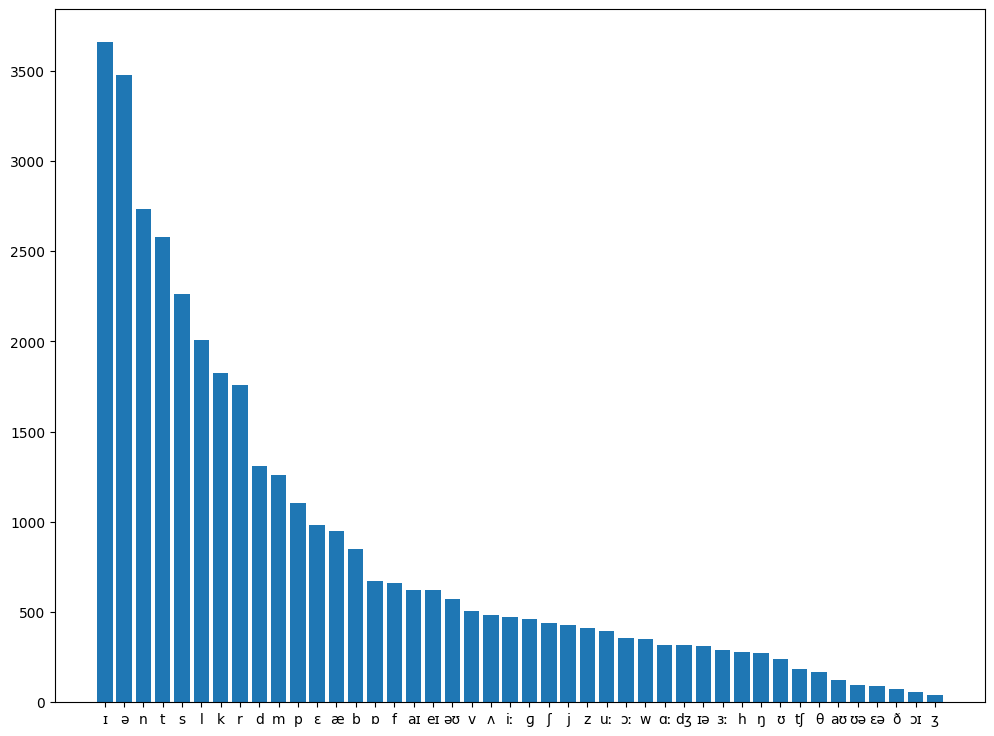

In [50]:
phonemes_female, frequencies_female = get_phonemes_frequencies(df_female)
frequencies_female_sorted, phonemes_female_sorted = zip(*sorted(zip(frequencies_female, phonemes_female), reverse=True))
fig, ax = plt.subplots(figsize=(12, 9))

ax.bar(phonemes_female_sorted, frequencies_female_sorted)
plt.show()

#### Как видно, существуют очень редко встречающиеся фонемы, поэтому нужно дообогатить датасет аугментациями, начиная с самых редких звуков. Пока аудио грузится на ноут, ...

#### 4. Напишем токенизатор

In [51]:
import json
from transformers import PreTrainedTokenizer

In [52]:
phonemes_vocab = {"<pad>": 0, "<s>": 1, "</s>": 2, "<unk>": 3, "|": 4}
i = 5

for phoneme in phonemes_sorted:
    
    phonemes_vocab[phoneme] = i
    i += 1 

In [53]:
with open("phonemes_vocab.json", "w") as json_file:
    json.dump(phonemes_vocab, json_file)

In [53]:
class Phoneme_Tokenizer(PreTrainedTokenizer):
    
    def __init__(self, phonemes_vocab_file, add_path="", **kwargs):
        
        self.vocab = self.load_vocab(add_path + phonemes_vocab_file)            
        self.id_to_tokens = {id: token for token, id in self.vocab.items()}
            
        self.unk_token = "<unk>"
        self.pad_token = "<pad>"
        
        super().__init__(unk_token = "<unk>", pad_token = "<pad>", **kwargs)   
                    
    def _tokenize(self, transcription):
        
        if transcription[:2] + transcription[-2:] == "/  /":
            transcription = transcription[2:-2]
            
        phonemes = []
        
        skip = False            
        
        for i in range(len(transcription)):
            
            if skip:
                skip = False
                continue
            
            if i < len(transcription) - 1:
                
                if transcription[i:i+2] in binary_phonemes_list:
                    
                    phonemes.append(transcription[i:i+2])
                    skip = True
                
                elif transcription[i] in unary_phonemes_list:
                    phonemes.append(transcription[i])
                    
                else:
                    phonemes.append("<unk>")
                    
                continue
            
            if transcription[i] in unary_phonemes_list:
                phonemes.append(transcription[i])
                    
            else:
                phonemes.append("<unk>")
                
        return phonemes
    
    def _convert_id_to_token(self, index):
        return self.id_to_tokens.get(index, self.unk_token)
    
    def _convert_token_to_id(self, token):
        return self.vocab.get(token, self.vocab["<unk>"])
    
    def convert_tokens_to_string(self, tokens):
        return "".join(tokens)
    
    @staticmethod
    def load_vocab(phonemes_file_path):
        with open(phonemes_file_path, "r") as json_file:
            return json.load(json_file)
    
    def get_vocab(self):
        return self.vocab

In [54]:
tokenizer = Phoneme_Tokenizer("phonemes_vocab.json")

In [55]:
sample = "/ ɑːdvɑːk /"

In [56]:
encoded_sample = tokenizer("ɑːdvɑːk", return_tensors="pt").input_ids
encoded_sample

tensor([[32, 11, 23, 32,  9]])

In [57]:
tokenizer.batch_decode(encoded_sample)

['ɑːdvɑːk']

## Дообогатим датасет аугментациями

Методы аугментации, которые выдал Deepseek

---

### **1. Методы во временной области**  
- **Изменение скорости (Time Stretching):**  
  Ускорение или замедление аудио без изменения тона (например, с помощью алгоритма PSOLA).  
- **Сдвиг по времени (Time Shifting):**  
  Случайное смещение аудиосигнала вперед или назад (добавление тишины в начале/конце).  
- **Временное маскирование (Time Masking):**  
  Обнуление случайных временных отрезков (полезно для спектрограмм в SpecAugment).  
- **Обрезка/нарезка (Cropping):**  
  Вырезание фрагментов из аудио для создания новых коротких записей.  
- **Инверсия сигнала (Polarity Inversion):**  
  Изменение полярности волны (зеркальное отражение сигнала).  

---

### **2. Методы в частотной области**  
- **Изменение тона (Pitch Shifting):**  
  Повышение или понижение частоты сигнала (например, на ±4 полутона).  
- **Частотное маскирование (Frequency Masking):**  
  Обнуление случайных частотных полос в спектрограмме (как в SpecAugment).  
- **Фильтрация (Low/High-Pass Filter):**  
  Удаление высоких или низких частот для имитации ограничений оборудования.  

---

### **3. Добавление шумов и артефактов**  
- **Гауссовский/белый шум (Gaussian/White Noise):**  
  Наложение случайного шума с заданной амплитудой.  
- **Импульсный шум (Impulse Noise):**  
  Добавление коротких "щелчков" или помех.  
- **Фоновые звуки (Background Noise):**  
  Смешивание с шумом улицы, музыкой или разговорами.  
- **Реверберация (Reverb):**  
  Имитация акустики помещений (например, с помощью импульсных откликов).  

---

### **4. Динамические преобразования**  
- **Изменение громкости (Gain Augmentation):**  
  Случайное усиление или ослабление амплитуды сигнала.  
- **Клиппинг (Clipping):**  
  Искусственное ограничение амплитуды для создания искажений.  
- **Компрессия (Dynamic Range Compression):**  
  Сжатие динамического диапазона для выравнивания громкости.  

---

### **5. Пространственные преобразования (для стерео)**  
- **Панорамирование (Panorama Shift):**  
  Изменение баланса между левым и правым каналами.  
- **Сведение в моно (Mono Conversion):**  
  Преобразование стереозаписи в моно для уменьшения зависимости от каналов.  

---

### **6. Генеративные методы**  
- **GAN (Generative Adversarial Networks):**  
  Генерация новых аудиосэмплов с помощью нейросетей.  
- **Диффузионные модели (Diffusion Models):**  
  Создание реалистичных аудиозаписей через постепенное удаление шума.  
- **TTS (Text-to-Speech):**  
  Синтез речи с разными голосами и интонациями.  

---

### **7. Составные методы**  
- **Случайные комбинации:**  
  Одновременное применение нескольких аугментаций (например, шум + изменение скорости + реверберация).  
- **Параметрический поиск:**  
  Автоматический подбор параметров аугментации с помощью оптимизации.  

---

### **Примеры библиотек**  
- **Python:**  
  - `audiomentations` (готовые преобразования: шум, реверберация, дисторшн).  
  - `librosa` (базовые операции: изменение тона, скорости).  
  - `torchaudio` (аугментации для PyTorch).  
  - `specaugment` (маскирование для спектрограмм).  

---

### **Как выбрать метод?**  
- **Для распознавания речи (ASR):**  
  Изменение скорости, добавление шума, реверберация, временное/частотное маскирование.  
- **Для классификации звуков:**  
  Наложение фоновых шумов, изменение тона, пространственные преобразования.  
- **Для генерации аудио:**  
  GAN, диффузионные модели, TTS.  

---

### **Важно!**  
- Сохраняйте смысл данных: например, в ASR изменение тона не должно искажать слова.  
- Тестируйте аугментации: некоторые преобразования могут ухудшить качество данных.  
- Используйте баланс: слишком агрессивная аугментация приведет к переобучению.  

In [58]:
import soundfile as sf
from audiomentations import Compose, AddGaussianNoise, Gain, TimeStretch, PitchShift
from tqdm import tqdm

import warnings

warnings.filterwarnings('ignore')

In [59]:
def make_path(url):
    return "audios/" + url.split("/")[-1]

In [60]:
df_new["path"] = df_new["url"].apply(make_path)

In [61]:
augmenter = Compose([
    AddGaussianNoise(p=0.5), # Небольшой шум
    PitchShift(min_semitones=-2, max_semitones=2, p=0.5), # Малое изменение тона
    TimeStretch(min_rate=0.5, max_rate=2, p=0.5, leave_length_unchanged=False), # небольшое ускорение / замедление
    Gain(min_gain_db=-12, max_gain_db=20, p=0.5), # небольшое изменение грмокости
])

In [62]:
data = {
    "word": [],
    "transcription": [],
    "gender": [],
    "url": [],
    "path": []
}

In [63]:
male_aug = 3
female_aug = 11
aug_dir = "augmented_audios/"

In [64]:
df_augmented = pd.DataFrame(data)

for i in tqdm(range(len(df_new))):
    
    row = df_new.iloc[[i]]
    
    audio, sr = sf.read(row["path"].iloc[0])
    
    if len(audio.shape) > 1:
        audio = audio.mean(axis=1)
    
    n_aug = male_aug if row["gender"].iloc[0] == "мужчина" else female_aug
    
    for j in range(n_aug):
        
        file_name = f"aug_{j}_" + row["path"].iloc[0].split("/")[-1]
        
        path = aug_dir + file_name
        
        augmented_audio = augmenter(samples=audio, sample_rate=sr)
        sf.write(path, augmented_audio, sr)
        
        new_row = row.copy()
        new_row["path"] = path
        
        df_augmented = pd.concat([df_augmented, new_row])

  2%|▏         | 368/21244 [00:30<28:34, 12.17it/s]


KeyboardInterrupt: 

In [ ]:
aug_df.to_csv("augmented_dataset.csv")

In [ ]:
import pandas as pd

In [ ]:
aug_df = pd.read_csv("augmented_dataset.csv", delimiter="№")

C:\Users\Egor\AppData\Local\Temp\ipykernel_16484\2093525578.py:1: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  aug_df = pd.read_csv("augmented_dataset.csv", delimiter="№")


In [ ]:
del aug_df["Unnamed: 0"]
del aug_df["Unnamed: 0.1"]

In [ ]:
aug_df

,Unnamed: 0,word,transcription,gender,url,path
0,0,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_0_c0_9438478_39_12928.mp3
1,1,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_1_c0_9438478_39_12928.mp3
2,2,aardvark,ɑːdvɑːk,мужчина,https://audio12.forvo.com/audios/mp3/c/0/c0_94...,augmented_audios/aug_2_c0_9438478_39_12928.mp3
3,3,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...,augmented_audios/aug_0_83_9410408_39_12931.mp3
4,4,aaron,ɛərən,мужчина,https://audio12.forvo.com/audios/mp3/8/3/83_94...,augmented_audios/aug_1_83_9410408_39_12931.mp3
...,...,...,...,...,...,...
110264,110264,zoophilia,zəʊəfɪlɪə,мужчина,https://audio12.forvo.com/audios/mp3/9/8/98_89...,augmented_audios/aug_1_98_8986016_39_426975_16...
110265,110265,zoophilia,zəʊəfɪlɪə,мужчина,https://audio12.forvo.com/audios/mp3/9/8/98_89...,augmented_audios/aug_2_98_8986016_39_426975_16...
110266,110266,zoster,zɒstə,мужчина,https://audio12.forvo.com/audios/mp3/b/6/b6_89...,augmented_audios/aug_0_b6_8981864_39_601922.mp3
110267,110267,zoster,zɒstə,мужчина,https://audio12.forvo.com/audios/mp3/b/6/b6_89...,augmented_audios/aug_1_b6_8981864_39_601922.mp3


---
---
### Начнём аугментации со слов, в которых есть самые редкие звуки

# To be continued...